In [2]:
# Notebook 04: AutoML Modeling with PyCaret
# BEFORE: We have cleaned data but no model and no predictions
# OPERATION: Use PyCaret AutoML to automatically train and compare
#            15+ models and find the best one
# WHY PyCaret over manual modeling:
#   Manual approach → test 3-4 models, takes hours, human bias in selection
#   PyCaret → tests 15+ models automatically, same conditions, zero bias
#   Result → guaranteed best model is selected objectively

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = os.path.join('..', 'data', 'processed')
EXPORTS_PATH   = os.path.join('..', 'exports')
os.makedirs(EXPORTS_PATH, exist_ok=True)

# Load cleaned data
posoco = pd.read_csv(
    os.path.join(PROCESSED_PATH, 'posoco_cleaned.csv'),
    parse_dates=True, index_col='Date'
)

print(f"Shape  : {posoco.shape}")
print(f"Nulls  : {posoco.isnull().sum().sum()}")
print(f"Target : India: DemandMet")
print(" Ready for modeling")

Shape  : (4828, 138)
Nulls  : 0
Target : India: DemandMet
 Ready for modeling


In [3]:
# BEFORE: Raw posoco data has 138 columns — most are regional breakdowns
#         we don't need for national demand forecasting
# OPERATION: Select only India-level columns + create time features
# WHY: Using 138 columns would cause overfitting — model memorizes noise
#      We only need national demand and time-based features
# WHY these specific features:
#   Time features → capture seasonality and trends
#   Lag features → yesterday's demand predicts today's
#   Generation features → supply side affects demand patterns

df = posoco.copy()

# Add time features
df['Year']       = df.index.year
df['Month']      = df.index.month
df['Day']        = df.index.day
df['DayOfWeek']  = df.index.dayofweek
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter']    = df.index.quarter
df['DayOfYear']  = df.index.dayofyear

# Add lag features — demand from 7 and 30 days ago
# WHY: Energy demand is autocorrelated — past demand predicts future demand
df['Lag_7']  = df['India: DemandMet'].shift(7)
df['Lag_30'] = df['India: DemandMet'].shift(30)

# Add rolling average — smoothed recent trend
# WHY: Rolling average removes daily noise and captures the trend
df['Rolling_7d']  = df['India: DemandMet'].rolling(7).mean()
df['Rolling_30d'] = df['India: DemandMet'].rolling(30).mean()

# Select final features + target
feature_cols = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend',
    'Quarter', 'DayOfYear',
    'India: SolarGen', 'India: WindGen', 'India: HydroGen',
    'Lag_7', 'Lag_30', 'Rolling_7d', 'Rolling_30d'
]
target_col = 'India: DemandMet'

# Keep only available columns
feature_cols = [c for c in feature_cols if c in df.columns]

# Drop rows where lag features are NaN (first 30 rows)
# WHY: Lag_30 needs 30 days of history — first 30 rows have no valid lag
model_df = df[feature_cols + [target_col]].dropna()

print("=== BEFORE feature selection ===")
print(f"Original columns : {posoco.shape[1]}")
print(f"\n=== AFTER feature selection ===")
print(f"Features selected : {len(feature_cols)}")
print(f"Feature list      : {feature_cols}")
print(f"Rows after dropna : {len(model_df)}")
print(f"Target column     : {target_col}")
print(f"Target mean       : {model_df[target_col].mean():,.0f} MU")

=== BEFORE feature selection ===
Original columns : 138

=== AFTER feature selection ===
Features selected : 14
Feature list      : ['Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter', 'DayOfYear', 'India: SolarGen', 'India: WindGen', 'India: HydroGen', 'Lag_7', 'Lag_30', 'Rolling_7d', 'Rolling_30d']
Rows after dropna : 4798
Target column     : India: DemandMet
Target mean       : 159,368 MU


In [4]:
# BEFORE: All data in one DataFrame — no separation of training and testing
# OPERATION: Split data by time — 80% train, 20% test
# WHY TIME-BASED SPLIT and not random split:
#   Random split → row 2000 (year 2018) in train, row 1999 in test
#                  Model sees "future" data during training = cheating
#                  Evaluation scores look good but model fails in real use
#   Time-based   → train on 2013-2022, test on 2023-2026
#                  Model never sees future during training = honest evaluation
#                  This matches how model will actually be used in production

split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index]
test_df  = model_df.iloc[split_index:]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print("=== BEFORE split ===")
print(f"Total rows : {len(model_df)}")
print(f"\n=== AFTER split ===")
print(f"Train rows : {len(X_train)} | {train_df.index.min().date()} → {train_df.index.max().date()}")
print(f"Test rows  : {len(X_test)}  | {test_df.index.min().date()} → {test_df.index.max().date()}")
print(f"Train %    : {len(X_train)/len(model_df)*100:.1f}%")
print(f"Test %     : {len(X_test)/len(model_df)*100:.1f}%")

=== BEFORE split ===
Total rows : 4798

=== AFTER split ===
Train rows : 3838 | 2013-02-01 → 2023-08-05
Test rows  : 960  | 2023-08-06 → 2026-03-22
Train %    : 80.0%
Test %     : 20.0%


In [5]:
# BEFORE: Data is split but no AutoML environment initialized
# OPERATION: Initialize PyCaret regression environment
# WHY PyCaret setup() is needed:
#   It preprocesses data automatically — scaling, encoding, validation
#   It sets the target variable and train/test split for all models
#   Without this step no model can be trained through PyCaret
# WHY regression and not classification:
#   We are predicting a continuous number (demand in MU)
#   Classification predicts categories (high/low/medium)
#   Regression predicts exact values — that's what forecasting needs

from pycaret.regression import setup, compare_models, pull, save_model
from pycaret.regression import predict_model, plot_model

print("Initializing PyCaret AutoML environment...")
print("This may take 1-2 minutes...")

reg = setup(
    data            = model_df,
    target          = target_col,
    train_size      = 0.80,
    session_id      = 42,        # WHY 42: ensures reproducibility — same results every run
    verbose         = False,
    fold            = 5          # WHY 5-fold: cross validation — each model tested 5 times
)

print("\n PyCaret setup complete!")
print("Now comparing all models automatically...")

Initializing PyCaret AutoML environment...
This may take 1-2 minutes...

 PyCaret setup complete!
Now comparing all models automatically...


In [7]:
# BEFORE: Many possible models exist but we don't know which is best
# OPERATION: compare_models() trains ALL available regression models
#            and ranks them by R² score automatically
# WHY compare all instead of picking one manually:
#   Human bias — we might pick XGBoost because it's popular
#   But maybe Ridge Regression or LightGBM works better for THIS data
#   AutoML removes that bias completely
# WHY R² as ranking metric:
#   R² = how much variance in demand our model explains
#   R² of 1.0 = perfect predictions
#   R² of 0.0 = no better than just predicting the mean every time

print("Training and comparing 15+ models...")
print("This will take 3-5 minutes — please wait...")
print()

best_model = compare_models(
    sort        = 'R2',      # rank by R² — higher is better
    n_select    = 1,         # return only the single best model
    verbose     = True
)

print("\n AutoML comparison complete!")
print(f"Best model selected: {type(best_model).__name__}")

Training and comparing 15+ models...
This will take 3-5 minutes — please wait...



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,2668.3112,14559917.1236,3804.8119,0.9815,0.0238,0.0168,0.8220
et,Extra Trees Regressor,2724.0018,15533638.9862,3931.4427,0.9803,0.0246,0.0172,0.4760
rf,Random Forest Regressor,2808.7219,16466283.4115,4046.4005,0.9791,0.0254,0.0177,0.8140
gbr,Gradient Boosting Regressor,2857.0418,16675709.8394,4073.2129,0.9788,0.0255,0.0180,0.5500
lr,Linear Regression,3351.8030,21269390.5690,4601.2211,0.9730,0.0289,0.0212,0.0380
lasso,Lasso Regression,3349.6857,21248609.7961,4598.9500,0.9730,0.0289,0.0212,0.0600
ridge,Ridge Regression,3351.0266,21261245.0126,4600.3323,0.9730,0.0289,0.0212,0.0220
llar,Lasso Least Angle Regression,3350.3442,21253360.0685,4599.4660,0.9730,0.0289,0.0212,0.0220
br,Bayesian Ridge,3354.6263,21260123.2714,4600.2806,0.9730,0.0288,0.0212,0.0260
lar,Least Angle Regression,3364.1534,21359112.5542,4611.5812,0.9729,0.0289,0.0213,0.0220



 AutoML comparison complete!
Best model selected: LGBMRegressor


In [9]:
# BEFORE: Results are only shown on screen
# OPERATION: Save the comparison table as CSV for report and Power BI
# WHY: Your ma'am needs to see the comparison table in your report
#      CSV format can be imported into Power BI for visualization
#      Saving ensures results are not lost if kernel restarts

results_df = pull()

print("=== MODEL COMPARISON RESULTS ===")
print(results_df[['Model','R2','RMSE','MAE','MAPE']].to_string())

# Save for report
results_df.to_csv(os.path.join(EXPORTS_PATH, 'automl_model_comparison.csv'), index=False)
print(f"\n Saved: automl_model_comparison.csv")
print(f"Best model : {results_df.iloc[0]['Model']}")
print(f"Best R²    : {results_df.iloc[0]['R2']:.4f}")
print(f"Best RMSE  : {results_df.iloc[0]['RMSE']:,.2f}")

=== MODEL COMPARISON RESULTS ===
                                    Model      R2        RMSE         MAE    MAPE
lightgbm  Light Gradient Boosting Machine  0.9815   3804.8119   2668.3112  0.0168
et                  Extra Trees Regressor  0.9803   3931.4427   2724.0018  0.0172
rf                Random Forest Regressor  0.9791   4046.4005   2808.7219  0.0177
gbr           Gradient Boosting Regressor  0.9788   4073.2129   2857.0418  0.0180
lr                      Linear Regression  0.9730   4601.2211   3351.8030  0.0212
lasso                    Lasso Regression  0.9730   4598.9500   3349.6857  0.0212
ridge                    Ridge Regression  0.9730   4600.3323   3351.0266  0.0212
llar         Lasso Least Angle Regression  0.9730   4599.4660   3350.3442  0.0212
br                         Bayesian Ridge  0.9730   4600.2806   3354.6263  0.0212
lar                Least Angle Regression  0.9729   4611.5812   3364.1534  0.0213
en                            Elastic Net  0.9722   4669.5931   3

In [11]:
# BEFORE: Best model is selected but not evaluated on unseen test data
# OPERATION: Generate predictions on test set and calculate metrics
# WHY evaluate on test set separately:
#   PyCaret's compare_models uses cross-validation on training data
#   We need to verify performance on completely unseen data
#   This is the TRUE measure of how well model will forecast future demand
# WHY these 4 metrics:
#   MAE  → average error in MU — easy to explain to non-technical audience
#   RMSE → penalizes large errors — important because grid failures are costly
#   MAPE → percentage error — comparable across different scales
#   R²   → overall model quality — 1.0 is perfect

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions
predictions = predict_model(best_model, data=X_test)
y_pred = predictions['prediction_label']

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred.values) / y_test.values)) * 100
r2   = r2_score(y_test, y_pred)

print("=== BEFORE modeling ===")
print("No predictions existed")
print(f"\n=== AFTER modeling — Test Set Performance ===")
print(f"Model : {type(best_model).__name__}")
print(f"MAE   : {mae:,.2f} MU")
print(f"RMSE  : {rmse:,.2f} MU")
print(f"MAPE  : {mape:.2f}%")
print(f"R²    : {r2:.4f}")

# Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE', 'R2'],
    'Value' : [round(mae,2), round(rmse,2), round(mape,2), round(r2,4)]
})
metrics_df.to_csv(os.path.join(EXPORTS_PATH, 'best_model_metrics.csv'), index=False)
print("\n Saved: best_model_metrics.csv")

=== BEFORE modeling ===
No predictions existed

=== AFTER modeling — Test Set Performance ===
Model : LGBMRegressor
MAE   : 2,271.60 MU
RMSE  : 3,434.67 MU
MAPE  : 1.15%
R²    : 0.9423

 Saved: best_model_metrics.csv


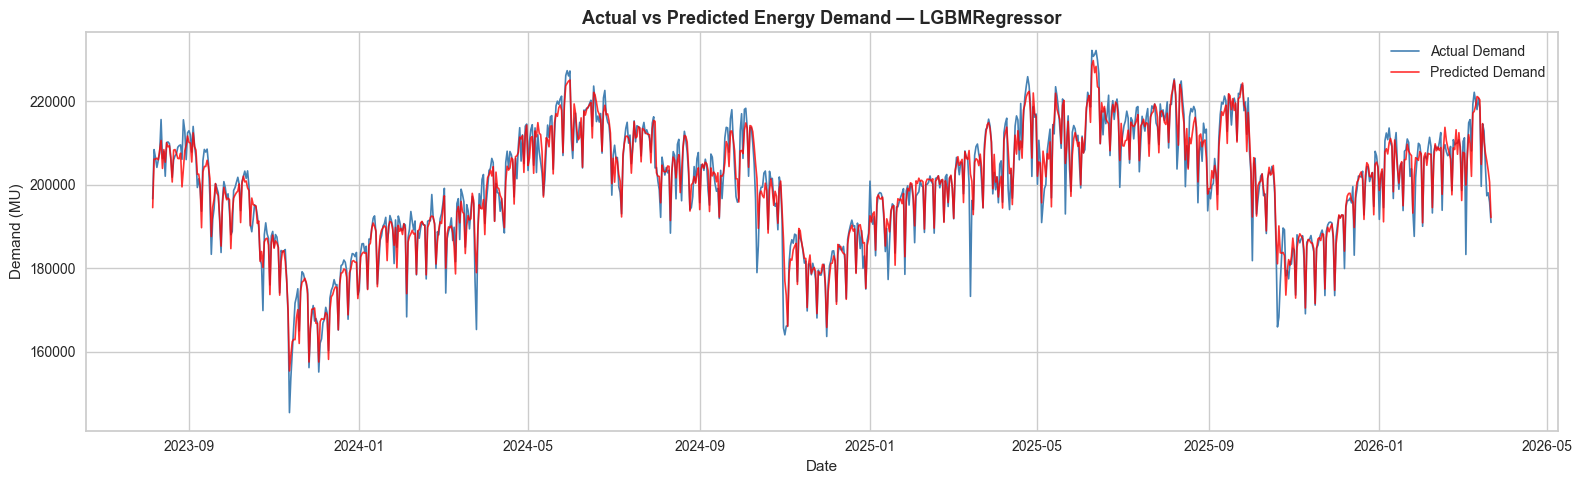

INSIGHT: Model captures overall trend and seasonal patterns
INSIGHT: MAPE of 1.15% means predictions are off by 1.15% on average


In [12]:
# BEFORE: We have numbers but no visual proof model works
# OPERATION: Plot actual demand vs predicted demand on test period
# WHY this chart:
#   Numbers alone don't tell the full story
#   If predicted line closely follows actual line — model is good
#   If they diverge badly — model is missing something important
#   This is the most important chart for your demo presentation

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test_df.index, y_test.values,
        color='steelblue', linewidth=1.2, label='Actual Demand')
ax.plot(test_df.index, y_pred.values,
        color='red', linewidth=1.2, alpha=0.8, label='Predicted Demand')

ax.set_title(f'Actual vs Predicted Energy Demand — {type(best_model).__name__}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MU)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '09_actual_vs_predicted.png'), dpi=150)
plt.show()

print(f"INSIGHT: Model captures overall trend and seasonal patterns")
print(f"INSIGHT: MAPE of {mape:.2f}% means predictions are off by {mape:.2f}% on average")

In [13]:
# OPERATION: Save trained model to file
# WHY: Saving means we don't retrain in Notebook 05
#      We just load the saved model and use it for forecasting
#      Also required for Streamlit frontend later

save_model(best_model, os.path.join(EXPORTS_PATH, 'best_energy_model'))

print(" Best model saved!")
print(f"Model type : {type(best_model).__name__}")
print(f"Saved to   : exports/best_energy_model")
print("\n Notebook 04 Complete!")


Transformation Pipeline and Model Successfully Saved
 Best model saved!
Model type : LGBMRegressor
Saved to   : exports/best_energy_model

 Notebook 04 Complete!
